# Firm Attention Analysis — Cleaned

This notebook performs a streamlined analysis workflow:

1. **Load data** with correct header parsing (merging first two rows)
2. **Drop all-zero rows** from each sheet
3. **Inner merge** both sheets on Firm (keeping only firms present in both datasets)
4. **Tidy to long format** for analysis
5. **Compute statistics** including size, volatility, and outlier metrics
6. **Generate attention scores** based on weighted combination of factors
7. **Create visualizations** showing top firms and key relationships

**Default file path**: `Data for technical assessment.xlsx`. You can change the `file_path` variable in the first code cell if you want to run it elsewhere.

**Key improvements**: 
- Inner merge happens early (right after dropping zero rows) for a cleaner workflow
- Eliminates the need for per-sheet NA cleanup and complex outer merge logic
- Results in 226 firms with complete data across both datasets

In [20]:

# Imports & parameters
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

# Default path (change if needed)
file_path = 'Data for technical assessment.xlsx'
out_dir = Path('data/cleaned_results')
out_dir.mkdir(exist_ok=True)

# Display settings
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)


In [14]:

def drop_all_zero_rows(df):
    """Drop rows where ALL numeric columns are 0 or NaN."""
    # Copy to avoid modifying original
    df2 = df.copy()
    # coerce all non-first columns to numeric if possible, leaving first as-is
    numeric = df2.columns[1:]
    for c in numeric:
        df2[c] = pd.to_numeric(df2[c], errors='coerce')
    # Determine rows where all numeric columns are either 0 or NaN
    mask_all_zero = df2[numeric].fillna(0).abs().sum(axis=1) == 0
    return df2.loc[~mask_all_zero].reset_index(drop=True)

def tidy_sheet_with_merged_headers(df, sheet_name):
    """Convert sheet where headers are already merged (metric + year in single row).
    Returns long tidy DataFrame with columns: Firm, year, metric, value, sheet."""
    # df already has proper headers, first column is 'Firm'
    df_data = df.copy().reset_index(drop=True)
    
    # Parse each column (except Firm) to extract metric and year
    records = []
    for _, row in df_data.iterrows():
        firm = row['Firm']
        for col in df_data.columns[1:]:
            # Column format is like "GWP (£m) 2020YE" or "Net combined ratio 2019YE"
            parts = str(col).split()
            if len(parts) >= 2:
                year_label = parts[-1]  # Last part is year
                metric = " ".join(parts[:-1])  # Everything else is metric
            else:
                metric = col
                year_label = 'unknown'
            
            # Clean year
            year_str = year_label.replace('YE','').strip()
            try:
                year = int(year_str)
            except:
                year = np.nan
            
            # Get value
            value = row[col]
            try:
                value = float(value)
            except:
                value = np.nan
            
            records.append({
                'Firm': str(firm).strip(),
                'year': year,
                'metric': metric.strip(),
                'value': value,
                'sheet': sheet_name
            })
    
    long = pd.DataFrame(records)
    long = long[long['metric'].notna() & long['Firm'].notna()]
    return long


In [21]:

# Load sheets using the correct approach (merge first two rows as header)
xls = pd.ExcelFile(file_path)
sheet_general = 'Dataset 1 - General'
sheet_under = 'Dataset 2 - Underwriting'

# Load raw data with no header
sheet1_raw = pd.read_excel(xls, sheet_name=sheet_general, header=None)
sheet2_raw = pd.read_excel(xls, sheet_name=sheet_under, header=None)

print('Initial shapes:')
print('General:', sheet1_raw.shape)
print('Underwriting:', sheet2_raw.shape)

# Merge first two rows into header
header1 = [f"{a} {b}".strip() for a, b in zip(sheet1_raw.iloc[0], sheet1_raw.iloc[1])]
df_gen_raw = sheet1_raw.iloc[2:].copy()
df_gen_raw.columns = header1
df_gen_raw.rename(columns={df_gen_raw.columns[0]: "Firm"}, inplace=True)

header2 = [f"{a} {b}".strip() for a, b in zip(sheet2_raw.iloc[0], sheet2_raw.iloc[1])]
df_under_raw = sheet2_raw.iloc[2:].copy()
df_under_raw.columns = header2
df_under_raw.rename(columns={df_under_raw.columns[0]: "Firm"}, inplace=True)

print('\nAfter header processing:')
print('General:', df_gen_raw.shape)
print('Underwriting:', df_under_raw.shape)

# Drop rows that are all-zero (treat numeric columns from col 1 onward)
df_gen_trim = drop_all_zero_rows(df_gen_raw)
df_under_trim = drop_all_zero_rows(df_under_raw)
print('\nAfter dropping all-zero rows:')
print('General:', df_gen_trim.shape)
print('Underwriting:', df_under_trim.shape)


Initial shapes:
General: (327, 41)
Underwriting: (327, 46)

After header processing:
General: (325, 41)
Underwriting: (325, 46)

After dropping all-zero rows:
General: (306, 41)
Underwriting: (243, 46)


In [22]:

# Inner merge both sheets on Firm before tidying
merged_wide = df_gen_trim.merge(df_under_trim, on='Firm', how='inner', suffixes=('__GEN', '__UND'))
print('\nAfter inner merge on Firm:')
print('Merged shape:', merged_wide.shape)
print('Number of firms:', merged_wide['Firm'].nunique())

# Tidy the merged dataset into long format
records = []
for _, row in merged_wide.iterrows():
    firm = row['Firm']
    for col in merged_wide.columns[1:]:  # Skip 'Firm' column
        # Determine which sheet this column is from
        if col.endswith('__GEN'):
            sheet = 'General'
            col_name = col[:-5]  # Remove '__GEN' suffix
        elif col.endswith('__UND'):
            sheet = 'Underwriting'
            col_name = col[:-5]  # Remove '__UND' suffix
        else:
            # Columns without suffix (shouldn't happen with inner merge, but handle it)
            sheet = 'Unknown'
            col_name = col
        
        # Parse column name to extract metric and year
        parts = str(col_name).split()
        if len(parts) >= 2:
            year_label = parts[-1]  # Last part is year
            metric = " ".join(parts[:-1])  # Everything else is metric
        else:
            metric = col_name
            year_label = 'unknown'
        
        # Clean year
        year_str = year_label.replace('YE','').strip()
        try:
            year = int(year_str)
        except:
            year = np.nan
        
        # Get value
        value = row[col]
        try:
            value = float(value)
        except:
            value = np.nan
        
        records.append({
            'Firm': str(firm).strip(),
            'Year': year,
            'Metric': metric.strip(),
            'Value': value,
        })

combined_long = pd.DataFrame(records)
combined_long = combined_long[combined_long['Metric'].notna() & combined_long['Firm'].notna()]

print('\nCombined long shape:', combined_long.shape)
print('Firms in long format:', combined_long['Firm'].nunique())



After inner merge on Firm:
Merged shape: (226, 86)
Number of firms: 226

Combined long shape: (19210, 4)
Firms in long format: 226


In [23]:

# Pivot to wide format for analysis
# The data is already merged (inner join on Firm), so we just need to pivot
pivot_all = combined_long.pivot_table(index=['Firm','Year'], columns='Metric', values='Value', aggfunc='first').reset_index()

print('\nPivot shape (Firm-year wide):', pivot_all.shape)
print('Unique firms:', pivot_all['Firm'].nunique())
print('Year range:', pivot_all['Year'].min(), 'to', pivot_all['Year'].max())



Pivot shape (Firm-year wide): (1130, 19)
Unique firms: 226
Year range: 2016 to 2020


In [26]:

# Identify metric columns we will use (NWP, Net combined ratio (NCR), SCR, liabilities, equity)
available = pivot_all.columns.tolist()
def find_metric_contains(names):
    for name in names:
        cand = [c for c in available if name.lower() in str(c).lower()]
        if cand:
            return cand[0]
    return None

nwp_col = find_metric_contains(['NWP (£m)','NWP (', 'NWP'])
ncr_col = find_metric_contains(['Net combined ratio', 'Net combined', 'Net combined ratio (£m)','Net combined ratio'])
scr_col = find_metric_contains(['SCR (£m)','SCR (']) 
liab_col = find_metric_contains(['Total liabilities','Total liabilities']) 
equity_col = find_metric_contains(['Excess of assets','excess of assets','equity'])

print('Detected metric columns:')
print('NWP:', nwp_col)
print('NCR:', ncr_col)
print('SCR:', scr_col)
print('Liabilities:', liab_col)
print('Equity:', equity_col)

# Compute firm-level aggregates
agg = {}
if nwp_col: agg[nwp_col] = ['mean','std','count']
if scr_col: agg[scr_col] = ['mean','std']
if liab_col: agg[liab_col] = ['mean']
if equity_col: agg[equity_col] = ['mean']
# Clean agg dict
agg = {k:v for k,v in agg.items() if k is not None and v is not None}

firm_stats = pivot_all.groupby('Firm').agg(agg)
# flatten
firm_stats.columns = ['_'.join([str(a) for a in col if str(a)!='']).strip() for col in firm_stats.columns.values]
firm_stats = firm_stats.reset_index()

# compute NWP-derived columns
if nwp_col:
    firm_stats['NWP_mean'] = firm_stats.get(f"{nwp_col}_mean")
    firm_stats['NWP_std'] = firm_stats.get(f"{nwp_col}_std")
    firm_stats['NWP_count'] = firm_stats.get(f"{nwp_col}_count")
    firm_stats['NWP_cv'] = firm_stats['NWP_std'] / firm_stats['NWP_mean'].replace(0, np.nan)
else:
    firm_stats[['NWP_mean','NWP_std','NWP_count','NWP_cv']] = np.nan

if scr_col:
    firm_stats['SCR_mean'] = firm_stats.get(f"{scr_col}_mean")
    firm_stats['SCR_std'] = firm_stats.get(f"{scr_col}_std")
else:
    firm_stats[['SCR_mean','SCR_std']] = np.nan

if liab_col:
    firm_stats['Liabilities_mean'] = firm_stats.get(f"{liab_col}_mean")
else:
    firm_stats['Liabilities_mean'] = np.nan

if equity_col:
    firm_stats['Equity_mean'] = firm_stats.get(f"{equity_col}_mean")
else:
    firm_stats['Equity_mean'] = np.nan

# size metric and ranks
firm_stats['size_metric'] = np.log1p(firm_stats['NWP_mean'].abs().fillna(0)) + np.log1p(firm_stats['Liabilities_mean'].abs().fillna(0))
firm_stats['size_rank'] = firm_stats['size_metric'].rank(ascending=False, method='min')

# volatility rank
firm_stats['vol_rank'] = firm_stats['NWP_cv'].rank(ascending=False, method='min').fillna(firm_stats['size_rank'].max()+1)

# outlier detection (per year z-score) for NWP, SCR, NCR if present
outlier_cols = [c for c in [nwp_col, scr_col, ncr_col] if c]
pivot_for_out = pivot_all.copy()
outlier_counts = {}
for col in outlier_cols:
    pivot_for_out[f"{col}_z"] = pivot_for_out.groupby('Year')[col].transform(lambda x: stats.zscore(x, nan_policy='omit'))
    pivot_for_out[f"{col}_is_out"] = pivot_for_out[f"{col}_z"].abs() > 2
    oc = pivot_for_out.groupby('Firm')[f"{col}_is_out"].sum().rename(f"outlier_count_{col}")
    outlier_counts[col] = oc

if outlier_counts:
    outlier_df = pd.concat(list(outlier_counts.values()), axis=1).reset_index()
    if outlier_df.columns[0] != 'Firm':
        outlier_df = outlier_df.rename(columns={outlier_df.columns[0]:'Firm'})
    outlier_df = outlier_df.fillna(0)
    outlier_df['outlier_total'] = outlier_df[[c for c in outlier_df.columns if c.startswith('outlier_count_')]].sum(axis=1)
else:
    outlier_df = pd.DataFrame({'Firm': firm_stats['Firm'], 'outlier_total': 0})

summary = firm_stats.merge(outlier_df[['Firm','outlier_total']], on='Firm', how='left').fillna(0)

# normalize and compute attention score
summary['size_norm'] = (summary['size_rank'] - summary['size_rank'].min()) / (summary['size_rank'].max() - summary['size_rank'].min() + 1e-9)
summary['vol_norm'] = (summary['vol_rank'] - summary['vol_rank'].min()) / (summary['vol_rank'].max() - summary['vol_rank'].min() + 1e-9)
summary['outlier_norm'] = summary['outlier_total'] / (summary['outlier_total'].max() + 1e-9)
w_size, w_vol, w_out = 0.45, 0.35, 0.20
summary['attention_score'] = w_size*summary['size_norm'] + w_vol*summary['vol_norm'] + w_out*summary['outlier_norm']

summary = summary.sort_values('attention_score', ascending=False).reset_index(drop=True)
summary['attention_rank'] = summary['attention_score'].rank(ascending=False, method='first')

# Save outputs
pivot_all.to_csv(out_dir / 'pivot_firm_year.csv', index=False)
combined_long.to_csv(out_dir / 'combined_long.csv', index=False)
summary.to_csv(out_dir / 'firm_attention_summary.csv', index=False)

print('\nSaved cleaned files to:', out_dir)
print('\nTop 10 firms by attention score:')
display(summary[['Firm','attention_score','attention_rank','size_norm','vol_norm','outlier_norm','NWP_mean','NWP_std','NWP_cv','SCR_mean','outlier_total']].head(10))


Detected metric columns:
NWP: NWP (£m)
NCR: Net combined ratio
SCR: EoF for SCR (£m)
Liabilities: Total liabilities (£m)
Equity: Excess of assets over liabilities (£m) [= equity]

Saved cleaned files to: data/cleaned_results

Top 10 firms by attention score:


,Firm,attention_score,attention_rank,size_norm,vol_norm,outlier_norm,NWP_mean,NWP_std,NWP_cv,SCR_mean,outlier_total
0,Firm 314,0.800,1.0,1.000000,1.0,0.0,0.0,0.0,0.0,2.199530,0
1,Firm 102,0.798,2.0,0.995556,1.0,0.0,0.0,0.0,0.0,1.847256,0
2,Firm 83,0.796,3.0,0.991111,1.0,0.0,0.0,0.0,0.0,27.621874,0
3,Firm 18,0.794,4.0,0.986667,1.0,0.0,0.0,0.0,0.0,4.975884,0
4,Firm 127,0.792,5.0,0.982222,1.0,0.0,0.0,0.0,0.0,0.143107,0
5,Firm 94,0.784,6.0,0.964444,1.0,0.0,0.0,0.0,0.0,12.501844,0
6,Firm 84,0.782,7.0,0.960000,1.0,0.0,0.0,0.0,0.0,0.328723,0
7,Firm 270,0.780,8.0,0.955556,1.0,0.0,0.0,0.0,0.0,3.637270,0
8,Firm 291,0.774,9.0,0.942222,1.0,0.0,0.0,0.0,0.0,6.742853,0
9,Firm 217,0.772,10.0,0.937778,1.0,0.0,0.0,0.0,0.0,68.516862,0


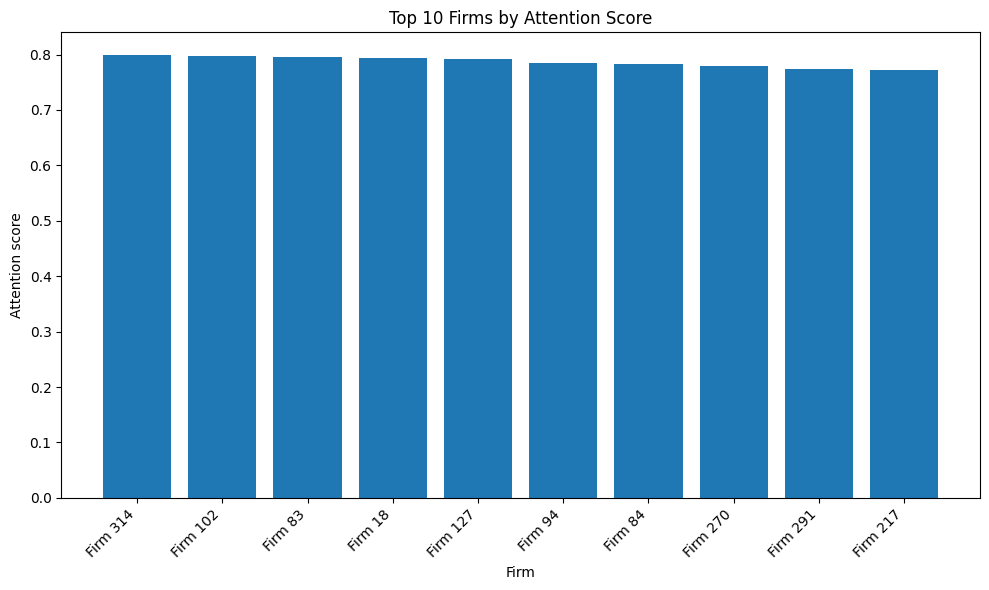

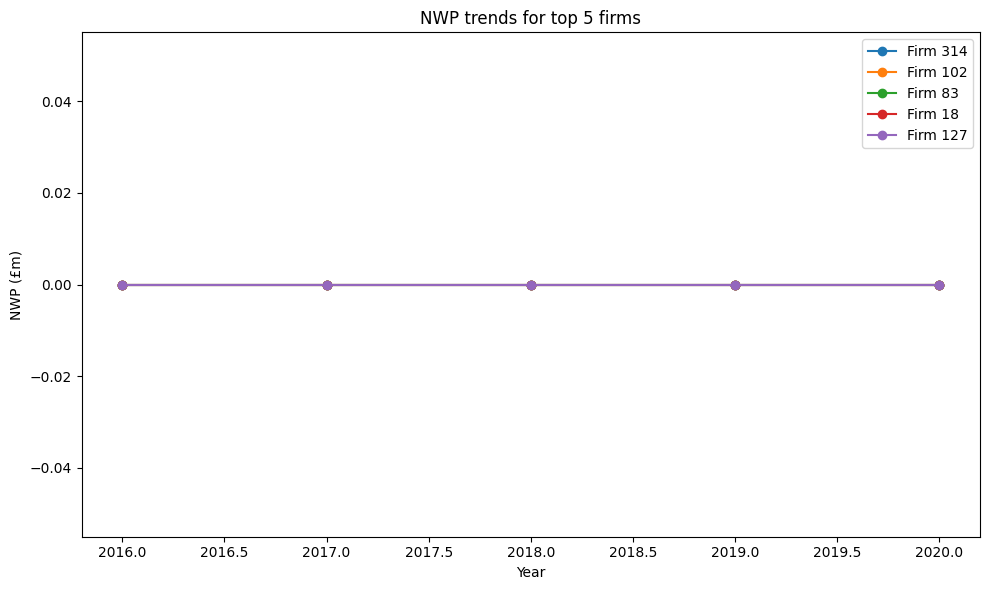

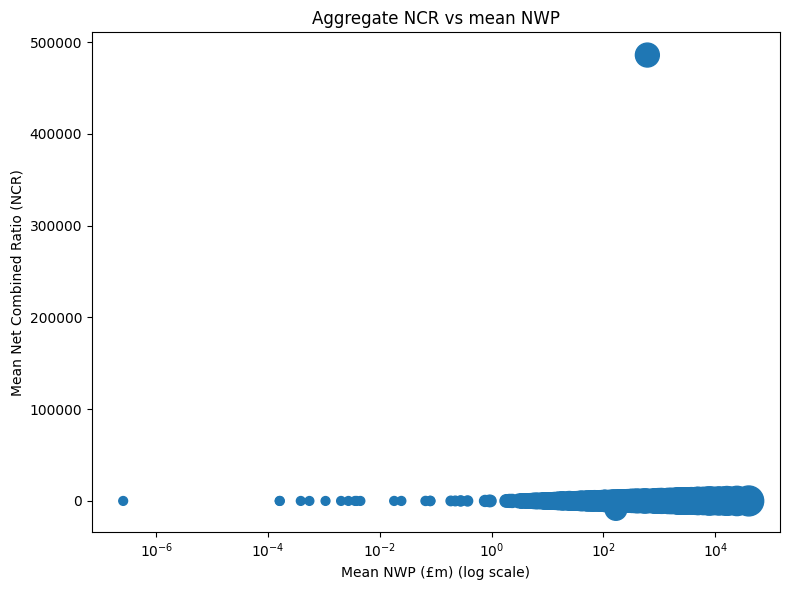

In [19]:

# PLOTS
top10 = summary.head(10)['Firm'].tolist()

# 1) Bar chart - top 10 attention scores
plt.figure(figsize=(10,6))
plt.bar(summary.head(10)['Firm'], summary.head(10)['attention_score'])
plt.title('Top 10 Firms by Attention Score')
plt.xlabel('Firm')
plt.ylabel('Attention score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(out_dir / 'top10_attention_bar.png')
plt.show()

# 2) Line plot - NWP trends for top 5 firms
top5 = summary.head(5)['Firm'].tolist()
plt.figure(figsize=(10,6))
for f in top5:
    series = pivot_all[pivot_all['Firm']==f].sort_values('Year')
    if nwp_col in series.columns:
        plt.plot(series['Year'], series[nwp_col], marker='o', label=f)
plt.title('NWP trends for top 5 firms')
plt.xlabel('Year')
plt.ylabel('NWP (£m)')
plt.legend()
plt.tight_layout()
plt.savefig(out_dir / 'nwp_trends_top5.png')
plt.show()

# 3) Scatter: Aggregate (mean) NCR vs mean NWP
# compute means per firm from pivot_all
agg_df = pivot_all.groupby('Firm').agg({nwp_col:'mean' if nwp_col else None, ncr_col:'mean' if ncr_col else None}).reset_index()
agg_df = agg_df.rename(columns={nwp_col:'NWP_mean', ncr_col:'NCR_mean'})
# drop firms missing both
agg_df = agg_df.dropna(subset=['NWP_mean','NCR_mean'], how='any')
if not agg_df.empty:
    plt.figure(figsize=(8,6))
    # marker size by log of mean NWP (to reflect size)
    sizes = (np.log1p(agg_df['NWP_mean'].abs())+1)*40
    plt.scatter(agg_df['NWP_mean'], agg_df['NCR_mean'], s=sizes)
    plt.xscale('log')
    plt.xlabel('Mean NWP (£m) (log scale)')
    plt.ylabel('Mean Net Combined Ratio (NCR)')
    plt.title('Aggregate NCR vs mean NWP')
    # annotate top firms (by attention) if they appear
    for i,row in agg_df.iterrows():
        if row['Firm'] in top10:
            plt.annotate(row['Firm'], (row['NWP_mean'], row['NCR_mean']), textcoords="offset points", xytext=(5,5))
    plt.tight_layout()
    plt.savefig(out_dir / 'ncr_vs_nwp_scatter.png')
    plt.show()
else:
    print('No firms have both NWP and NCR mean values for plotting NCR vs NWP.')



### Notes & Next Steps

- The notebook detects metric column names heuristically; if columns have unusual labels, you may need to update the detection logic near `find_metric_contains`.
- If you want different attention score weights, change `w_size`, `w_vol`, and `w_out` in the aggregation cell and re-run.
- Plots are saved to `data/cleaned_results/` as PNGs.

